In [1]:
STEP = 9
LEARNING_RATE = 1e-3 * 0.5 ** (STEP - 1)
BATCH_SIZE = 8
EPOCHS = 200
MAX_PATIENCE = 50 if STEP > 2 else 80
MIN_PATIENCE = MAX_PATIENCE // 2
print(f"Learning rate: {LEARNING_RATE}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

Learning rate: 3.90625e-06, Batch size: 8, Epochs: 200


In [2]:
from models.dataset import ImageDataset
from torch.utils.data import DataLoader
train_dataset = ImageDataset(hr_root=r"Data\DIV2K_train_HR", lr_root=r"Data\DIV2K_train_LR_bicubic\X4", lr_suffix="x4", ratio=4)
test_dataset = ImageDataset(hr_root=r"Data\valid_HR", lr_root=r"Data\valid_LR", lr_suffix="", ratio=4, train=False)
final_test_dataset = ImageDataset(hr_root=r"Data\DIV2K_valid_HR", lr_root=r"Data\DIV2K_valid_LR_bicubic\X4", lr_suffix="x4", ratio=4, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
final_test_loader = DataLoader(final_test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import os
from models.dlgsanet import DLGSANet
import torch.nn as nn
model = DLGSANet()
model_weights = f"weights/dlgsanet_{STEP:02d}.pth"
autocast = torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True)
if os.path.exists(model_weights):
    model.load_state_dict(torch.load(model_weights, map_location=device))
elif STEP > 1:
    model_weights = f"weights/dlgsanet_{STEP-1:02d}.pth"
    if os.path.exists(model_weights):
        model.load_state_dict(torch.load(model_weights, map_location=device))
model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
num_params = count_parameters(model)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 2150320


In [5]:
from tqdm import tqdm
best_loss = float("inf")
# Initial validation
model.eval()
running_test_loss = 0.0
with torch.inference_mode():
    for lr_images, hr_images in tqdm(test_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        with autocast:
            outputs = model(lr_images)
            loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
test_loss = running_test_loss / len(test_loader)

if test_loss < best_loss:
    best_loss = test_loss
    #torch.save(model.state_dict(), model_weights)
print(f"Initial Best Loss: {best_loss:.9f}")

100%|██████████| 200/200 [01:46<00:00,  1.87it/s]

Initial Best Loss: 0.024269257


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [1/200] Train Loss: 0.024924079 Val Loss: 0.024279659 Best: 0.024269257
Training time: 144.38s


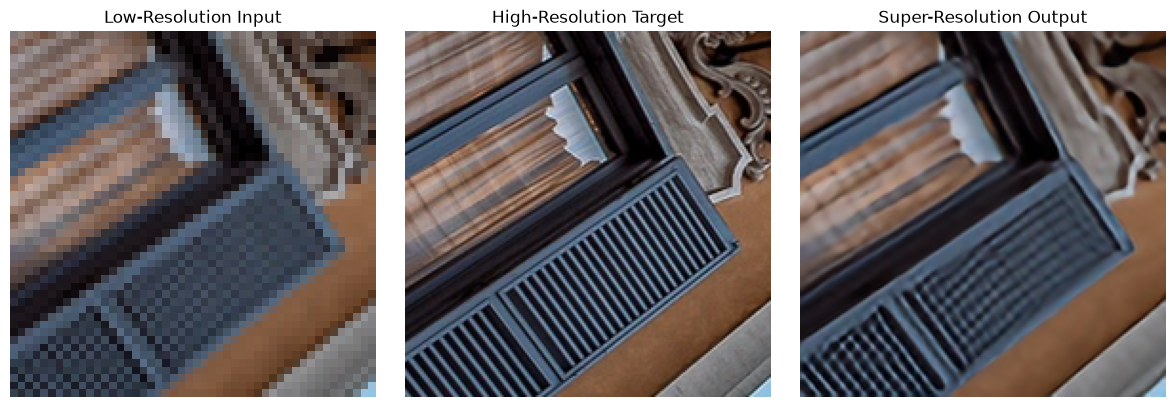

100%|██████████| 200/200 [01:51<00:00,  1.79it/s]


Epoch [2/200] Train Loss: 0.023769774 Val Loss: 0.024286164 Best: 0.024269257
Training time: 290.62s


100%|██████████| 200/200 [01:51<00:00,  1.80it/s]


Epoch [3/200] Train Loss: 0.024329901 Val Loss: 0.024281611 Best: 0.024269257
Training time: 431.81s


100%|██████████| 200/200 [01:51<00:00,  1.79it/s]


Epoch [4/200] Train Loss: 0.024596772 Val Loss: 0.024272371 Best: 0.024269257
Training time: 572.96s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [5/200] Train Loss: 0.024235200 Val Loss: 0.024266817 Best: 0.024266817
Training time: 716.67s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [6/200] Train Loss: 0.024874432 Val Loss: 0.024293819 Best: 0.024266817
Training time: 859.79s


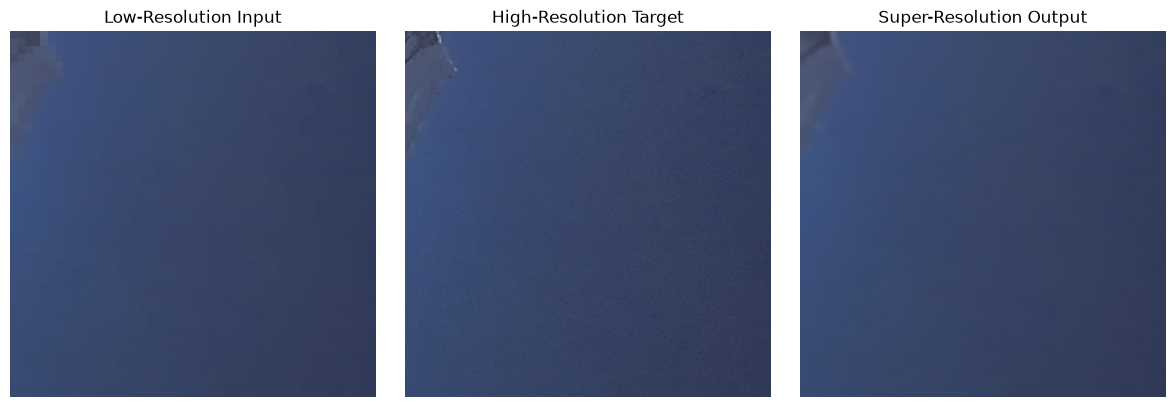

100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [7/200] Train Loss: 0.025012198 Val Loss: 0.024276219 Best: 0.024266817
Training time: 1003.36s


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [8/200] Train Loss: 0.025112738 Val Loss: 0.024271085 Best: 0.024266817
Training time: 1146.30s


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [9/200] Train Loss: 0.024423152 Val Loss: 0.024283356 Best: 0.024266817
Training time: 1289.72s


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [10/200] Train Loss: 0.025540645 Val Loss: 0.024278403 Best: 0.024266817
Training time: 1432.93s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [11/200] Train Loss: 0.024000517 Val Loss: 0.024276825 Best: 0.024266817
Training time: 1576.28s


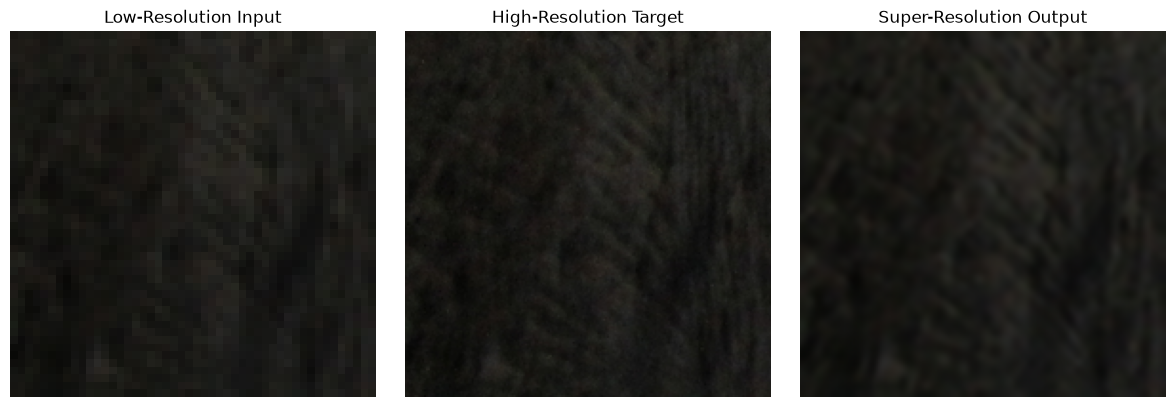

100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [12/200] Train Loss: 0.025269872 Val Loss: 0.024287395 Best: 0.024266817
Training time: 1719.95s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [13/200] Train Loss: 0.024975820 Val Loss: 0.024287116 Best: 0.024266817
Training time: 1863.23s


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [14/200] Train Loss: 0.024096938 Val Loss: 0.024282638 Best: 0.024266817
Training time: 2006.51s


100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


Epoch [15/200] Train Loss: 0.024760660 Val Loss: 0.024272072 Best: 0.024266817
Training time: 2149.67s


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [16/200] Train Loss: 0.025409177 Val Loss: 0.024282439 Best: 0.024266817
Training time: 2295.25s


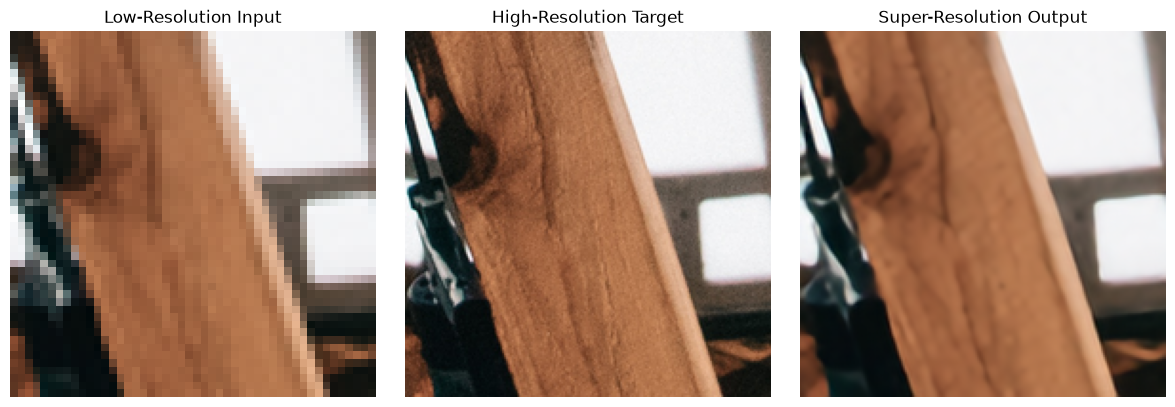

100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [17/200] Train Loss: 0.024949898 Val Loss: 0.024282440 Best: 0.024266817
Training time: 2440.75s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [18/200] Train Loss: 0.023467998 Val Loss: 0.024289076 Best: 0.024266817
Training time: 2585.32s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [19/200] Train Loss: 0.026280405 Val Loss: 0.024281748 Best: 0.024266817
Training time: 2730.26s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [20/200] Train Loss: 0.025085195 Val Loss: 0.024287028 Best: 0.024266817
Training time: 2874.56s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [21/200] Train Loss: 0.025721175 Val Loss: 0.024276255 Best: 0.024266817
Training time: 3019.60s


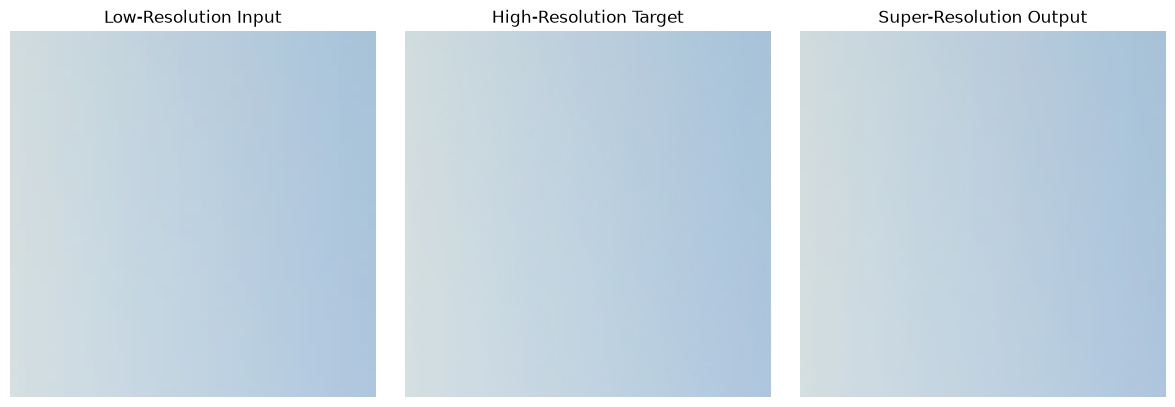

100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [22/200] Train Loss: 0.024070084 Val Loss: 0.024278495 Best: 0.024266817
Training time: 3163.92s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [23/200] Train Loss: 0.024850858 Val Loss: 0.024277824 Best: 0.024266817
Training time: 3308.23s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [24/200] Train Loss: 0.024317054 Val Loss: 0.024276030 Best: 0.024266817
Training time: 3452.48s


100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


Epoch [25/200] Train Loss: 0.025316295 Val Loss: 0.024280191 Best: 0.024266817
Training time: 3596.84s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [26/200] Train Loss: 0.024946298 Val Loss: 0.024276506 Best: 0.024266817
Training time: 3741.73s


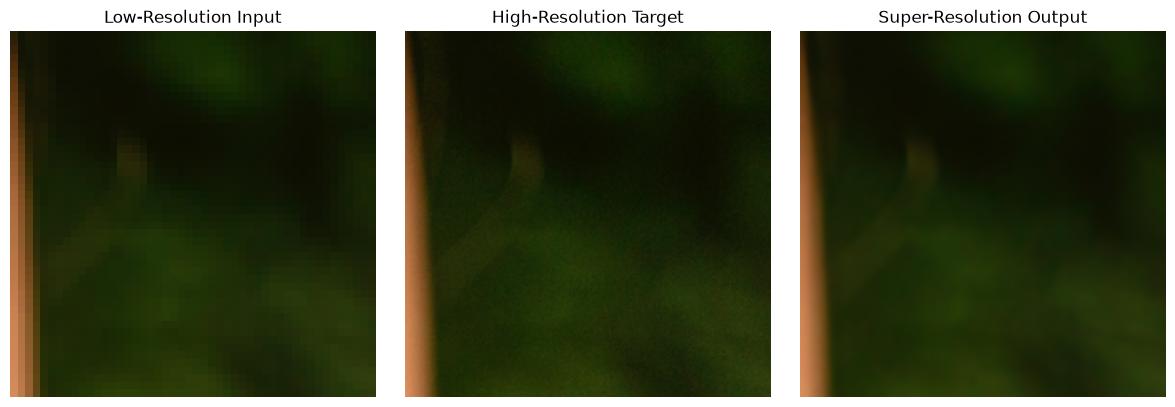

100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [27/200] Train Loss: 0.025778259 Val Loss: 0.024285174 Best: 0.024266817
Training time: 3886.36s


100%|██████████| 200/200 [01:55<00:00,  1.74it/s]


Epoch [28/200] Train Loss: 0.024878156 Val Loss: 0.024288088 Best: 0.024266817
Training time: 4032.07s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [29/200] Train Loss: 0.024362890 Val Loss: 0.024273564 Best: 0.024266817
Training time: 4176.44s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [30/200] Train Loss: 0.024947120 Val Loss: 0.024281201 Best: 0.024266817
Training time: 4320.30s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [31/200] Train Loss: 0.024892789 Val Loss: 0.024269605 Best: 0.024266817
Training time: 4464.83s


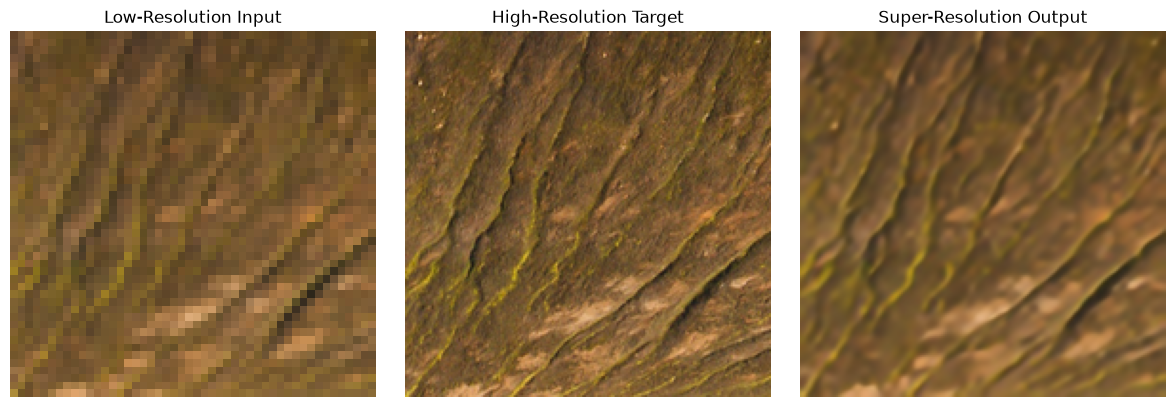

100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [32/200] Train Loss: 0.024775261 Val Loss: 0.024285598 Best: 0.024266817
Training time: 4609.37s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]


Epoch [33/200] Train Loss: 0.024454483 Val Loss: 0.024277752 Best: 0.024266817
Training time: 4753.18s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [34/200] Train Loss: 0.023891243 Val Loss: 0.024275547 Best: 0.024266817
Training time: 4897.42s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [35/200] Train Loss: 0.025025733 Val Loss: 0.024283183 Best: 0.024266817
Training time: 5041.72s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [36/200] Train Loss: 0.024133645 Val Loss: 0.024273584 Best: 0.024266817
Training time: 5186.13s


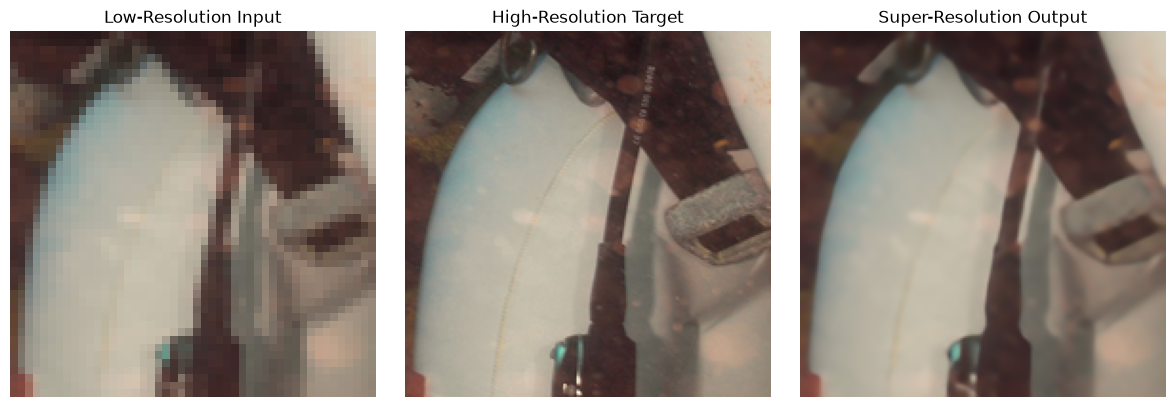

100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [37/200] Train Loss: 0.025483294 Val Loss: 0.024275033 Best: 0.024266817
Training time: 5331.13s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [38/200] Train Loss: 0.024592644 Val Loss: 0.024279249 Best: 0.024266817
Training time: 5475.21s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [39/200] Train Loss: 0.024869913 Val Loss: 0.024278014 Best: 0.024266817
Training time: 5619.91s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [40/200] Train Loss: 0.024162008 Val Loss: 0.024277738 Best: 0.024266817
Training time: 5764.18s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [41/200] Train Loss: 0.025323884 Val Loss: 0.024272413 Best: 0.024266817
Training time: 5908.83s


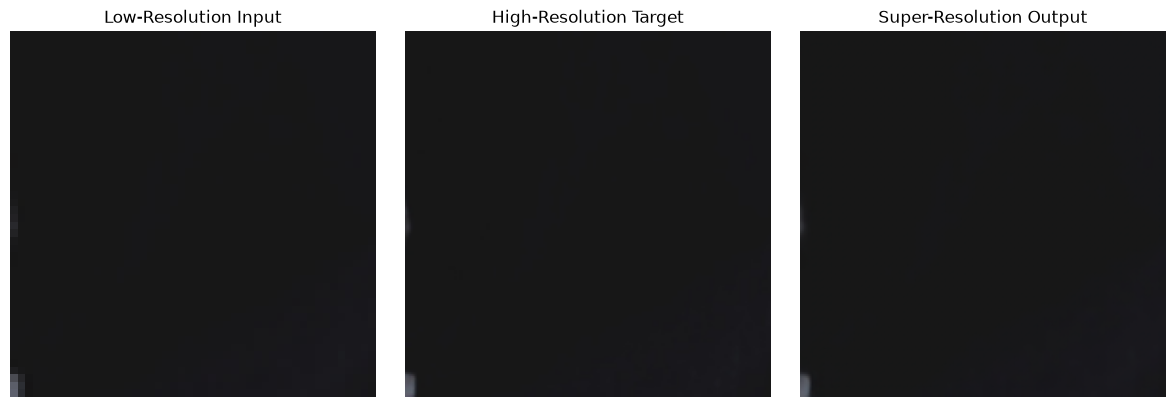

100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [42/200] Train Loss: 0.025825237 Val Loss: 0.024276157 Best: 0.024266817
Training time: 6053.96s


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [43/200] Train Loss: 0.024164485 Val Loss: 0.024280569 Best: 0.024266817
Training time: 6198.89s


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [44/200] Train Loss: 0.024401087 Val Loss: 0.024272826 Best: 0.024266817
Training time: 6344.41s


100%|██████████| 200/200 [01:54<00:00,  1.74it/s]


Epoch [45/200] Train Loss: 0.025498075 Val Loss: 0.024280375 Best: 0.024266817
Training time: 6489.80s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [46/200] Train Loss: 0.024937091 Val Loss: 0.024279507 Best: 0.024266817
Training time: 6637.54s


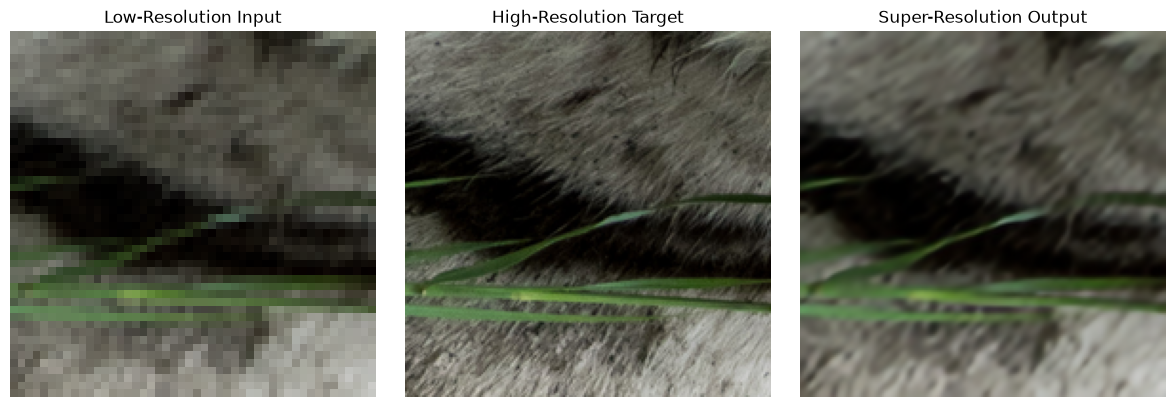

100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [47/200] Train Loss: 0.023996550 Val Loss: 0.024267059 Best: 0.024266817
Training time: 6782.55s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [48/200] Train Loss: 0.024902653 Val Loss: 0.024282929 Best: 0.024266817
Training time: 6927.27s


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [49/200] Train Loss: 0.025456771 Val Loss: 0.024269362 Best: 0.024266817
Training time: 7072.36s


100%|██████████| 200/200 [01:54<00:00,  1.75it/s]


Epoch [50/200] Train Loss: 0.024259189 Val Loss: 0.024274319 Best: 0.024266817
Training time: 7217.45s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [51/200] Train Loss: 0.024263476 Val Loss: 0.024270127 Best: 0.024266817
Training time: 7362.05s


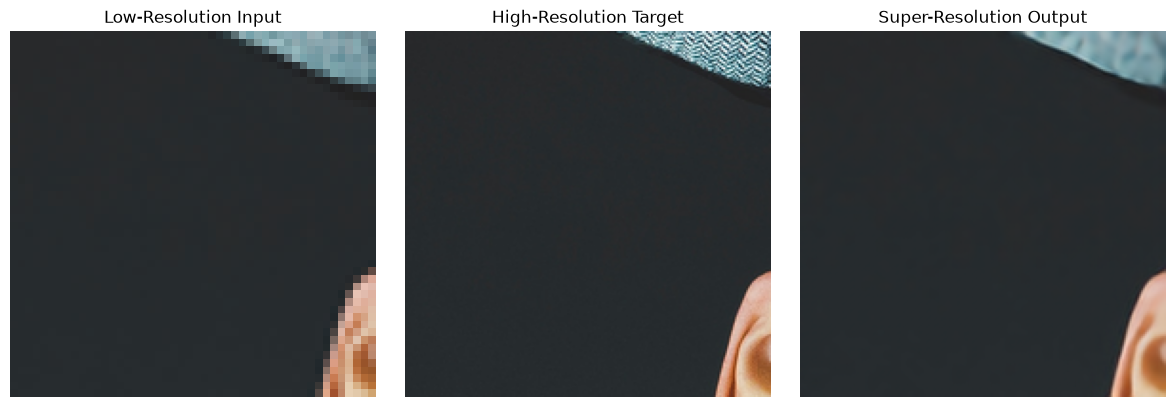

100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [52/200] Train Loss: 0.026207192 Val Loss: 0.024274914 Best: 0.024266817
Training time: 7507.24s


100%|██████████| 200/200 [01:53<00:00,  1.76it/s]


Epoch [53/200] Train Loss: 0.024947912 Val Loss: 0.024279222 Best: 0.024266817
Training time: 7651.53s


100%|██████████| 200/200 [01:53<00:00,  1.77it/s]

Early stopping triggered.


In [6]:
import random
import time
import matplotlib.pyplot as plt
patience = MAX_PATIENCE
train_losses = []
test_losses = []
time_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for lr_images, hr_images in tqdm(train_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        optimizer.zero_grad()
        with autocast:
            outputs = model(lr_images, False)
            loss = criterion(outputs, hr_images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    #scheduler.step()

    # Validation
    model.eval()
    running_test_loss = 0.0
    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
                loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
    test_loss = running_test_loss / len(test_loader)
    test_losses.append(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), f"weights/dlgsanet_{STEP:02d}.pth")
    if test_loss > best_loss:
        patience -= 1
        if patience == 0:
            print("Early stopping triggered.")
            break
    else:
        patience = round(MAX_PATIENCE - (MAX_PATIENCE - MIN_PATIENCE) * (epoch + 1) / EPOCHS)
        patience = max(5, patience)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.9f} "
        f"Val Loss: {test_loss:.9f} "
        f"Best: {best_loss:.9f}"
    )
    print(f"Training time: {time.time() - time_start:.2f}s")

    # Visualization
    if epoch % 5 == 0 or epoch == EPOCHS-1:
        with torch.inference_mode():
            random_idx = random.randrange(len(train_dataset))
            lr_image, hr_image = train_dataset[random_idx]
            lr_input = lr_image.unsqueeze(0).to(device)
            output = model(lr_input).squeeze(0).cpu()
            lr_image = lr_image.cpu()
            hr_image = hr_image.cpu()
        # [C, H, W] -> [H, W, C]
        lr_image = lr_image.permute(1, 2, 0).numpy()
        hr_image = hr_image.permute(1, 2, 0).numpy()
        output = output.permute(1, 2, 0).numpy()
        # Clamp because model output can slightly exceed [0, 1]
        lr_image = lr_image.clip(0, 1)
        hr_image = hr_image.clip(0, 1)
        output = output.clip(0, 1)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(lr_image)
        axs[0].set_title("Low-Resolution Input")
        axs[0].axis("off")

        axs[1].imshow(hr_image)
        axs[1].set_title("High-Resolution Target")
        axs[1].axis("off")

        axs[2].imshow(output)
        axs[2].set_title("Super-Resolution Output")
        axs[2].axis("off")

        plt.tight_layout()
        plt.show()

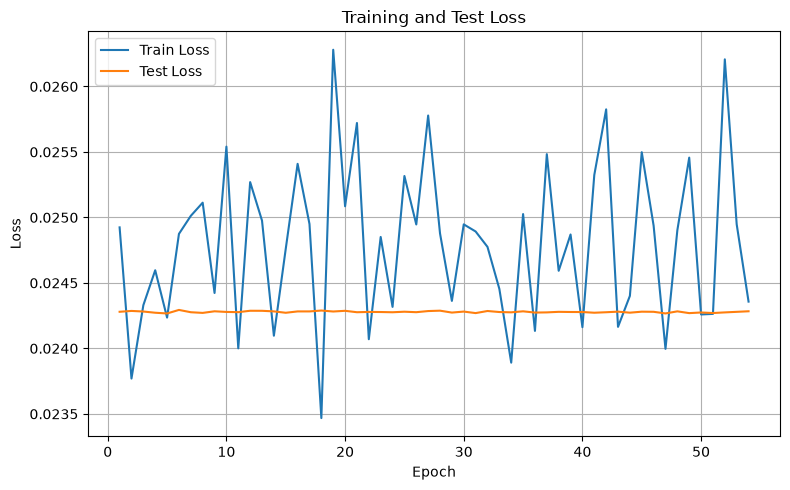

In [7]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import cv2
import numpy as np
from torchvision.transforms import v2
from skimage.metrics import structural_similarity as compare_ssim
def calculate_psnr(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf'),0  # Perfect match
    max_pixel = 1
    psnr = 10 * np.log10(max_pixel ** 2 / mse)
    return psnr,mse

def calculate_ssim(img1, img2, rgb=False):
    if rgb:
        img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    ssim, _ = compare_ssim(img1, img2, full=True, data_range=1.0,)
    return ssim

to_tensor = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [9]:
model.load_state_dict(torch.load(f"weights/dlgsanet_{STEP:02d}.pth", map_location=device))

def evaluate_test_loader(test_loader):
    model.eval()

    psnr_scores = []
    ssim_scores = []

    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
            outputs = outputs.clamp(0, 1).float()
            # NCHW -> NHWC
            outputs = outputs.cpu().permute(0, 2, 3, 1).numpy()
            hr_images = hr_images.cpu().permute(0, 2, 3, 1).numpy()

            for output, hr in zip(outputs, hr_images):
                psnr, _ = calculate_psnr(output, hr)
                ssim = calculate_ssim(output, hr)

                psnr_scores.append(psnr)
                ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"PSNR: min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )
    print(
        f"SSIM: min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results
results = evaluate_test_loader(final_test_loader)

100%|██████████| 100/100 [01:45<00:00,  1.06s/it]

PSNR: min=20.1280, mean=28.8322, max=43.8907
SSIM: min=0.5397, mean=0.8322, max=0.9899


In [10]:
from PIL import Image
def evaluate_bicubic(test_loader):
    psnr_scores = []
    ssim_scores = []

    for lr_images, hr_images in tqdm(test_loader):
        for lr, hr in zip(lr_images, hr_images):
            lr = lr.permute(1, 2, 0).numpy()
            hr = hr.permute(1, 2, 0).numpy()

            # LR tensor [0,1] -> PIL
            lr_pil = Image.fromarray(
                (lr * 255).clip(0, 255).astype(np.uint8)
            )

            # PIL bicubic upscale
            bicubic_pil = lr_pil.resize(
                (hr.shape[1], hr.shape[0]),
                Image.Resampling.BICUBIC,
            )

            # PIL -> [0,1] float
            bicubic = np.asarray(bicubic_pil).astype(np.float32) / 255.0

            psnr, _ = calculate_psnr(bicubic, hr)
            ssim = calculate_ssim(bicubic, hr)

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"Bicubic PSNR: "
        f"min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )

    print(
        f"Bicubic SSIM: "
        f"min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results

bicubic_results = evaluate_bicubic(final_test_loader)

100%|██████████| 100/100 [00:30<00:00,  3.24it/s]

Bicubic PSNR: min=16.4720, mean=26.6952, max=37.9498
Bicubic SSIM: min=0.4498, mean=0.7679, max=0.9810


In [11]:
import json

log = {
    "model_type": "DLGSANet",
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "psnr": results["psnr"]["mean"],
    "ssim": results["ssim"]["mean"],
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(log) + "\n")